Attacker and Defender strategy simaltaneous optimization

0. Setup
- Operation area's characteristics are globally shared
i.e. map bound, defender's search pattern, static obstacle locations, etc

1. Attacker optimiztaion (Joseph)
- Attacker generates initial guess based on setup

2. Defender optimization (Jeff)
- Defender optimize based on attacker's opitmized path

In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time
import math

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

# Import Customized python classes
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera
import Dynamic
import STP_RRTStar
import convex_map

importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar)
from STP_RRTStar import STP_RRTStar as rrt

In [2]:
# General Setup of World Parameter
map_size = (100, 100)
num_buildings = 5
num_direc_sensor = 5
num_omni_sensor = 2
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(15)
max_range = 50
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
rng_seed = 3

(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot: title={'center': 'Operation Map @ t = 0.00'}>)

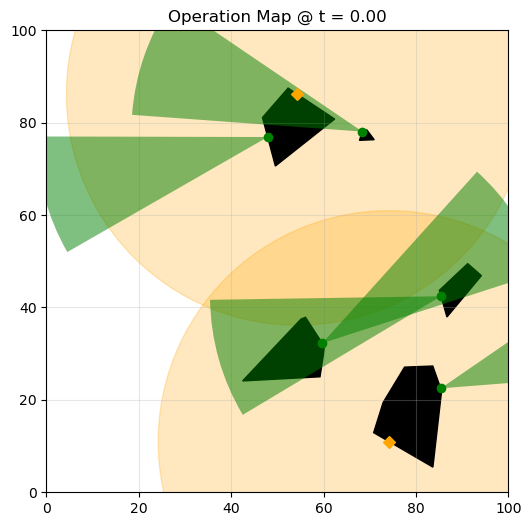

In [3]:
# Generate map
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

# Parse map_in dictionary
map_size = map_in['st']['size']

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [4]:
# Setup for Attacker Strategy: STP-RRT*
x0 = [0, 0, 0]
xf = [100, 100, 1200]
vmax = 10

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

In [5]:
# Generate Dynamic Map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1

Initial Attacker Path generation with STP-RRT*
- if run_rrt = True: Run a new attacker path
- if run_rrt = False: load old attacker path

STP-RRT* initialized
Total Cost: 2.643589127289646


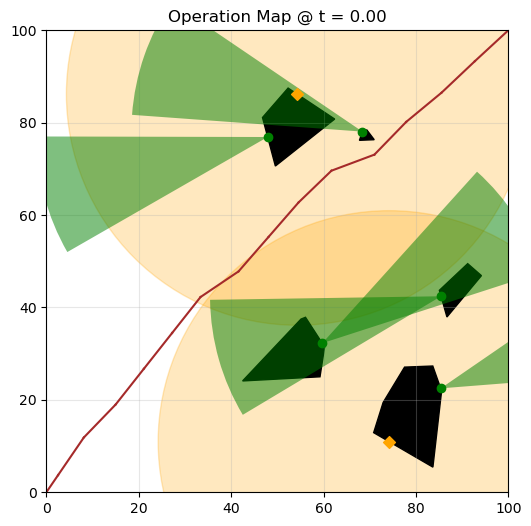

In [6]:
run_rrt = False
debug = True

# Initialize STP-RRT* Notebook
rrt_alg = rrt(vmax=vmax, xf=xf, map_size=map_size, vehicle=vehicle, cam_dict=cam_dict, dmap=dmap, max_time=1, map_in=map_in)

if run_rrt:
    
    # Run STP-RRT*
    # STP-RRT* Execution parameters
    x0 = x0          # start point
    nPartition = 5          # number of trees from the end point
    compTimeLimit = 600     # computation time limit

    min_dist = np.sqrt((x0[0]-xf[0])**2 + (x0[1]-xf[1])**2)
    min_time = min_dist/vmax

    tf0 = min_time                 # lower bound on end time randomization
    tfn = 25                # upper bound on end time randomization

    success_bool, comp_time, total_path_distance, total_path_time, success, path, V_start, V_goal, E_start, E_goal = rrt_alg.standard_Parallel_RRT(x0, nPartition, compTimeLimit, tf0, tfn, debug=debug)

    # Save Initial RRT result to a JSON File
    rrt_parameters={
        'success_bool': success_bool,
        'computation_time': comp_time,
        'path_distance': total_path_distance,
        'path_time': total_path_time,
        'path': path,
        'Vstart': V_start,
        'Vgoal': V_goal,
        'Estart': E_start,
        'Egoal': E_goal,
    }

    with open("json/zero_sum_game/rrt_parameters.json", "w") as f:
        json.dump(rrt_parameters, f, indent=4)
    print("STP-RRT* Results saved to rrt_parameters.json")
else:
    with open("json/zero_sum_game/rrt_parameters.json", 'r') as f:
        rrt_parameters = json.load(f)
        
    success_bool = rrt_parameters['success_bool']
    computation_time = rrt_parameters["computation_time"]
    total_path_distance = rrt_parameters["path_distance"]
    total_path_time = rrt_parameters["path_time"]
    path = rrt_parameters["path"]
    V_start = rrt_parameters["Vstart"]
    V_goal = rrt_parameters["Vgoal"]
    E_start = rrt_parameters["Estart"]
    E_goal = rrt_parameters["Egoal"]

# Visualize RRT result
visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5, algorithm_result=rrt_parameters)
print('Total Cost: '+str(rrt_alg.detection_cost_for_path(path)))

In [7]:
# Checking that the path obeys the maximum speed constraint
# Original Code written from Joseph
def verify_path_speed(path, vmax):
    """
    Verifies if any segment of the path exceeds vmax.
    Args:
        path: List of [x, y, t] points.
        vmax: Maximum allowed velocity.
    """
    # Convert to numpy array for easier calculation
    path_arr = np.array(path)
    
    # Calculate differences between consecutive points (dx, dy, dt)
    diffs = np.diff(path_arr, axis=0)
    dx = diffs[:, 0]
    dy = diffs[:, 1]
    dt = diffs[:, 2]

    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    
    # Avoid division by zero issues
    # (If dt is 0, the speed is effectively infinite if dist > 0)
    dt_safe = np.maximum(dt, 1e-8) 
    
    # Calculate speeds: v = d / t
    speeds = distances / dt_safe

    # Identify violations
    # Using a small tolerance (1e-5) for floating point comparisons
    violation_indices = np.where(speeds > vmax + 1e-5)[0] 
    
    if len(violation_indices) > 0:
        print(f"⚠️ Speed Violation Detected: {len(violation_indices)} segments exceed vmax ({vmax})")
        print(f"   Maximum Speed Found: {np.max(speeds):.4f}")
        
        # Print the first few violations
        print("   First 3 violations:")
        for i in violation_indices[:3]:
            print(f"     Seg {i}->{i+1}: Speed={speeds[i]:.2f}, Dist={distances[i]:.2f}, Time={dt[i]:.4f}")
    else:
        print(f"✅ Path is valid. Max speed found: {np.max(speeds):.4f} (Limit: {vmax})")

# Run the check on your variables
verify_path_speed(path, vehicle['v'])

✅ Path is valid. Max speed found: 8.5375 (Limit: 10)


In [8]:
# Helper function to compute Half-Space parameters for a convex polygon
# Original code written by Joseph
def get_polygon_half_space_constraints(poly_vertices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes A and b matrices for Ax <= b representation of a convex polygon.
    The constraint for avoidance will be A*p >= b + margin, or b - A*p <= -margin
    where p is the agent position.
    
    This function computes the *inward* pointing normal a_i and the offset b_i
    such that a_i^T * p <= b_i defines the INSIDE of the polygon.
    """
    
    A_list, b_list = [], []
    N_verts = len(poly_vertices)
    
    # Calculate centroid for inward/outward check
    # Note: polygon_centroid from convex_map uses NumPy but poly_vertices is a list of tuples initially
    # Ensure consistency; if poly_vertices is a NumPy array of (N, 2), this is fine.
    # We will use the centroid function from the imported convex_map
    centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])


        # CORRECTED CODE: Ensure poly_vertices is a list of tuples before passing to polygon_centroid
    # The map_in entry is a numpy array of arrays/lists (e.g., [[x1, y1], [x2, y2], ...])
    # We convert it back to the expected List[Tuple[float, float]] format for the utility function.
    # Let's ensure the inner elements are float/int pairs:
    if poly_vertices.ndim == 2:
        # This is a (N_verts, 2) array. Convert to a list of tuples.
        centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])
    else:
        # This must be the old [x, y, r] circular obstacle format that was accidentally left
        raise ValueError("Obstacle data is not a polygon vertex array. Check Cell 3 map setup.")
    
    for i in range(N_verts):
        v1 = poly_vertices[i]
        v2 = poly_vertices[(i + 1) % N_verts]
        
        # Edge vector (v2 - v1)
        ex, ey = v2[0] - v1[0], v2[1] - v1[1]
        
        # Candidate normal vector 1: n1 = (-ey, ex)
        # This is a counter-clockwise rotation from the edge vector (pointing left relative to edge direction v1->v2)
        n1 = np.array([-ey, ex])
        
        # Normalizing n1
        norm_n1 = np.linalg.norm(n1)
        if norm_n1 > 1e-6: # Avoid division by zero
            n1 = n1 / norm_n1

        # Check which normal points *inward* (toward the centroid)
        mid_point = (v1 + v2) / 2.0
        vec_to_centroid = np.array(centroid) - mid_point
        
        # # OLD WAY WITH NORMAL VECTORS POINTING INWARD
        # # If the dot product is negative, n1 points away from the centroid (outward)
        # # We want the *inward* normal, which points towards the centroid
        # if np.dot(n1, vec_to_centroid) < 0:
        #     # n1 is outward, so the inward normal is -n1
        #     a_i = -n1
        # else:
        #     # n1 is inward
        #     a_i = n1

        # --- FIX: ENSURE OUTWARD NORMAL ---
        # We want the normal to point AWAY from the centroid.
        # So dot product with vec_to_centroid should be NEGATIVE.
        
        if np.dot(n1, vec_to_centroid) < 0:
            # n1 points OUT (Good!)
            a_i = n1
        else:
            # n1 points IN (Bad, flip it)
            a_i = -n1


            
        # Calculate the offset b_i using a point on the boundary (v1)
        b_i = np.dot(a_i, v1)
        
        A_list.append(a_i)
        b_list.append(b_i)

    # Return as NumPy arrays for CasADi/NumPy operations
    return np.array(A_list), np.array(b_list)

# Pre-calculate A and b for all buildings
obstacle_constraints = []
for i in range(map_in['st']['n']):
    # map_in['st'][str(i)] is an (N_verts, 2) numpy array of vertices
    poly_vertices = map_in['st'][str(i)]
    A, b = get_polygon_half_space_constraints(poly_vertices)
    obstacle_constraints.append({'A': A, 'b': b})

print(f"Pre-processed {len(obstacle_constraints)} convex polygon obstacles.")

Pre-processed 5 convex polygon obstacles.


CasADi Optimization
- Setup for optimization process using CasADi 


In [9]:
# Optimize defender with given attacker:
# For now, we only move camera positoin 
# Constraints: camera position only move along building edge

# Camera position parameterization
# Position of camera:
cam_x_direc = cam_dict['directional']['x']
cam_y_direc = cam_dict['directional']['y']
cam_x_omni = cam_dict['omnidirectional']['x']
cam_y_omni = cam_dict['omnidirectional']['y']

# Building param:
alpha_vec = []
building_edge_vec = []      # p0,j, start of building edge
building_vector_vec = []    # ve,j, direction of building edge

# Find edge of convex polygon with camera:
def closest_edge(building, cam_xy, tol=None):
    P = np.asarray(building, dtype=float)
    x = np.asarray(cam_xy, dtype=float)
    M = P.shape[0]
    assert M >= 3

    Pn = np.vstack([P, P[0]])
    Ls = np.linalg.norm(Pn[1:] - Pn[:-1], axis=1)
    Lmean = float(np.mean(Ls))
    if tol is None:
        tol = 1e-3 * Lmean if Lmean > 0 else 1e-6

    best = None
    for i in range(M):
        p0_i, p1_i = Pn[i], Pn[i+1]
        v_i = p1_i - p0_i
        L2 = float(v_i @ v_i)
        if L2 < 1e-16:
            continue
        t_raw = float((x - p0_i) @ v_i / L2)
        t_clamped = min(1.0, max(0.0, t_raw))
        proj_i = p0_i + t_clamped * v_i
        d2_i = float(np.sum((x - proj_i)**2))
        if (best is None) or (d2_i < best["d2"]):
            L = np.sqrt(L2)
            t_hat = v_i / L
            n_hat = np.array([-t_hat[1], t_hat[0]])
            best = dict(
                edge_idx=i, alpha=t_clamped, proj=proj_i, d2=d2_i,
                tangent=t_hat, normal=n_hat, p0=p0_i, p1=p1_i
            )

    dist = float(np.sqrt(best["d2"])) if best is not None else np.inf
    is_on = bool(dist <= tol)

    vertex_hit = None
    vdist = np.linalg.norm(P - x, axis=1)
    v_idx = int(np.argmin(vdist))
    if float(vdist[v_idx]) <= tol:
        vertex_hit = v_idx

    # *** CRITICAL: compute v_e from best['p1'] and best['p0'], not loop vars ***
    v_e = best["p1"] - best["p0"]

    best.update({
        "is_on_building": is_on,
        "distance": dist,
        "vertex_hit": vertex_hit,
        "tol_used": float(tol),
        "v_e": v_e
    })
    return best

# Directional Sensor
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_direc']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_direc[n_sensor],cam_y_direc[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])

# Omnidirectional Sensor            
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_omni']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_omni[n_sensor], cam_y_omni[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])
            
# print('alpha_j:'+str(alpha_vec))
# print('building_vec: '+str(building_vector_vec))
# print('building_edge: '+str(building_edge_vec))

In [10]:
# Cost function at given time ti
# Use Elfes's model
def stage_detectability(x, y, t, S, dt1_vec, dt2_vec, lam_vec, beta_vec):
    """
    k(x, y, t; S) in [0, 1]
    x, y, t : casadi scalar of space-time vertex [x, y, t]
    S       : (2, M) casadi matrix of sensor position
    """
    M = S.shape[1]
    
    k_prod = 1.0
    
    for j in range(M):
        dx = x - S[0, j]
        dy = y - S[1, j]
        dist_to_target = ca.sqrt(dx**2 + dy**2)
        
        dt1 = dt1_vec[j]
        dt2 = dt2_vec[j]
        param_lambda = lam_vec[j]
        param_beta = beta_vec[j]
        
        k_j = ca.if_else(dist_to_target <= dt1, 1.0,
                ca.if_else(dist_to_target <= dt2, ca.exp(-param_lambda * (dist_to_target - dt1)**param_beta), 0.0)
        )
    
        k_prod *= (1 - k_j)
    
    # Probabilistic over sensors
    k_total = 1 - k_prod
    return k_total


# Trajectory cost C(A, S)
M = cam_dict['n']
n_d = cam_dict['n_direc']

dt1_vec  = []
dt2_vec  = []
lam_vec  = []
beta_vec = []

for j in range(M):
    sensor_type = 'directional' if j < n_d else 'omnidirectional'

    dt1_vec.append(cam_dict[sensor_type]['spec']['fov'][1] / 100.0)
    dt2_vec.append(cam_dict[sensor_type]['spec']['fov'][1])
    lam_vec.append(cam_dict['detection'][sensor_type]['param_lambda'])
    beta_vec.append(cam_dict['detection'][sensor_type]['param_beta'])

dt1_vec  = np.array(dt1_vec, dtype=float)
dt2_vec  = np.array(dt2_vec, dtype=float)
lam_vec  = np.array(lam_vec, dtype=float)
beta_vec = np.array(beta_vec, dtype=float)

def C_AS(A, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9):
    if A.shape[0] != 3:
        A = A.T
        
    if S.shape[0] != 2:
        S = S.T
        
    N = A.shape[1]
    C = 0
    
    for i in range(N):
        x_i = A[0, i]
        y_i = A[1, i]
        t_i = A[2, i]  # kept for signature compatibility (not used in pure range model)

        k_i = stage_detectability(x_i, y_i, t_i, S, dt1_vec, dt2_vec, lam_vec, beta_vec)
        # dt = ca.fmax(A[2,i+1] - A[2,i], 1e-3) if i < N-1 else 0.0
        # C += dt * (-ca.log(ca.fmax(1.0 - k_i, eps)))
        C += (-ca.log(ca.fmax(1.0 - k_i, eps)))
    return C

def build_C_function(N, M, dt1_vec, dt2_vec, lam_vec, beta_vec):
    A = ca.MX.sym('A', 3, N) # Attacker Trajectory
    S = ca.MX.sym('S', 2, M) # Defender Configuration
    C = C_AS(A, S, dt1_vec, dt2_vec, lam_vec, beta_vec)
    
    return ca.Function('DetectionCost', [A, S], [C], ['A', 'S'], ['cost'])
    # # Jacobian
    # dJdA = ca.jacobian(C, A)
    # dJdS = ca.jacobian(C, S)
    
    # return ca.Function('DetectionCost', [A, S], [C, dJdA, dJdS], ['A', 'S'], ['cost', 'dJdA', 'dJdS'])

In [11]:
def optimize_defender(A_fixed, alpha_prev_numeric=None, rho=0.0):
    opti_d = ca.Opti()

    M = cam_dict['n']

    # Decision variable: defender edge parameters
    alpha_j = opti_d.variable(M)
    opti_d.subject_to(alpha_j >= 0)
    opti_d.subject_to(alpha_j <= 1)

    # Sensor positions S(alpha)
    Sx, Sy = [], []
    for j in range(M):
        p1 = building_edge_vec[j]               # shape (2,)
        v  = building_vector_vec[j]             # shape (2,)
        s  = p1 + alpha_j[j] * v
        Sx.append(s[0])
        Sy.append(s[1])
    S = ca.vertcat(ca.hcat(Sx), ca.hcat(Sy))    # (2, M)

    # Attacker trajectory parameter (fixed for defender solve)
    N_eval = A_fixed.shape[1]
    A_param = opti_d.parameter(3, N_eval)
    opti_d.set_value(A_param, A_fixed)

    # Cost
    C = C_AS(A_param, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9)

    # Regularization anchor (optional but recommended in alternating)
    if alpha_prev_numeric is None:
        alpha_prev_numeric = 0.5 * np.ones(M)

    # if rho > 0:
    #     alpha_prev = opti_d.parameter(M)
    #     opti_d.set_value(alpha_prev, alpha_prev_numeric)
    #     opti_d.minimize(-C + rho * ca.sumsqr(alpha_j - alpha_prev))
    # else:
    opti_d.minimize(-C)

    # Warm start
    opti_d.set_initial(alpha_j, alpha_prev_numeric)

    # Solver
    # opti_d.solver("ipopt", {
    #     "print_time": False,
    #     "ipopt.print_level": 5,
    #     "ipopt.max_iter": 2000
    # },{
    #     'print_level': 0
    # })
    opti_d.solver(
        "ipopt",
        {  # CasADi options
            "print_time": False,
            "verbose": False,          # important: CasADi's own verbosity
        },
        {  # IPOPT options
            "print_level": 0,          # IPOPT verbosity
            "sb": "yes",               # suppress IPOPT banner
            "max_iter": 2000
        }
    )

    sol = opti_d.solve()

    alpha_star = sol.value(alpha_j)
    # S_star = sol.value(S)
    C_star = sol.value(C)
    S_star = np.column_stack([
        building_edge_vec[j] + alpha_star[j]*building_vector_vec[j] for j in range(M)
    ])
    return alpha_star, S_star, C_star

In [ ]:
# def optimize_attacker(S_fixed, path_init, v_max, X_init=None):
#     opti_a = ca.Opti()

#     # Fixed defender configuration
#     M = cam_dict['n']
#     S_param = opti_a.parameter(2, M)
#     opti_a.set_value(S_param, S_fixed)   # <-- use input

#     # Attacker initial path (for dimensions + init + boundary)
#     # path_arr = np.array(path_init, dtype=float)  # shape (K,3)
#     K = path_init.shape[1] # shape(3, K)
#     N_shooting = K - 1

#     # Decision variables at shooting nodes: [x, y, t]
#     X = opti_a.variable(3, N_shooting + 1)
#     pos_x = X[0, :]
#     pos_y = X[1, :]
#     t_node = X[2, :]

#     # Warm start
#     if X_init is not None:
#         # X_init is (3,K)
#         opti_a.set_initial(X, X_init)
#         # If you want boundaries consistent with your current iterate:
#         opti_a.subject_to(pos_x[0]  == X_init[0,0])
#         opti_a.subject_to(pos_y[0]  == X_init[1,0])
#         opti_a.subject_to(t_node[0] == X_init[2,0])
#         opti_a.subject_to(pos_x[-1]  == X_init[0,-1])
#         opti_a.subject_to(pos_y[-1]  == X_init[1,-1])
#         opti_a.subject_to(t_node[-1] == X_init[2,-1])
#     else:
#         opti_a.set_initial(pos_x, path_init[0, :])
#         opti_a.set_initial(pos_y, path_init[1, :])
#         opti_a.set_initial(t_node, path_init[2, :])
#         opti_a.subject_to(pos_x[-1]  == path_init[0,-1])
#         opti_a.subject_to(pos_y[-1]  == path_init[1,-1])
#         opti_a.subject_to(t_node[-1] == path_init[2,-1])

#     # Boundary conditions (start/goal fixed)
#     opti_a.subject_to(pos_x[0] == path_init[0, 0])
#     opti_a.subject_to(pos_y[0] == path_init[1, 0])
#     opti_a.subject_to(t_node[0] == path_init[2, 0])

#     opti_a.subject_to(pos_x[-1] == path_init[0, -1])
#     opti_a.subject_to(pos_y[-1] == path_init[1, -1])
#     opti_a.subject_to(t_node[-1] == path_init[2, -1])

#     # Time monotonicity
#     for k in range(N_shooting):
#         opti_a.subject_to(t_node[k+1] >= t_node[k])

#     # Kinematic feasibility (speed bound)
#     for k in range(N_shooting):
#         dx = pos_x[k+1] - pos_x[k]
#         dy = pos_y[k+1] - pos_y[k]
#         dt = t_node[k+1] - t_node[k]

#         opti_a.subject_to(dt >= 0)  # optional
#         opti_a.subject_to(dx*dx + dy*dy <= (v_max * dt)**2)

#     # Objective: minimize detection cost
#     C_attacker = C_AS(X, S_param, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9)
#     opti_a.minimize(C_attacker)

#     opti_a.solver(
#         "ipopt",
#         {  # CasADi options
#             "print_time": False,
#             "verbose": False,          # important: CasADi's own verbosity
#         },
#         {  # IPOPT options
#             "print_level": 0,          # IPOPT verbosity
#             "sb": "yes",               # suppress IPOPT banner
#             "max_iter": 2000
#         }
#     )

#     sol_a = opti_a.solve()

#     X_star = sol_a.value(X)                 # (3, K)
#     C_star = float(sol_a.value(C_attacker))

#     # In your current convention, attacker strategy passed to defender can be X_star directly
#     A_star = X_star

#     return X_star, A_star, C_star

## TODO
def optimize_attacker(S_fixed, A, v_max):
    start_time = A.T[0][2]
    end_time = A.T[-1][2]

    opti_a = ca.Opti()

    # Set timestamps
    N = 100  # number of time steps (tune this)

    # NEW: total travel time T is a decision variable (>= small positive)
    # T = opti_a.variable()
    S_param = opti_a.parameter(2, M)
    opti_a.set_value(S_param, S_fixed)    
    tau = opti_a.variable()
    T = ca.exp(tau)
    opti_a.subject_to(tau <= ca.log(end_time - start_time))  # duration limit


    # Derived: per-step time (CasADi expression)
    dt = T / N

    # opti_a.subject_to(T >= 1e-3)  # strictly positive
    opti_a.subject_to(T <= (end_time-start_time))
    dist_min = np.hypot(xf[0]-x0[0], xf[1]-x0[1])
    opti_a.subject_to(T >= dist_min / v_max)


    # Decision variables
    x = opti_a.variable(N+1)  # UAV x coords
    y = opti_a.variable(N+1)  # UAV y coords

    # Initial position constraints
    opti_a.subject_to(x[0] == x0[0])
    opti_a.subject_to(y[0] == x0[1])
    # Final position constraints
    opti_a.subject_to(x[-1] == xf[0])
    opti_a.subject_to(y[-1] == xf[1])

    # Map bounds
    opti_a.subject_to(opti_a.bounded(map_size[0], x, map_size[1]))
    opti_a.subject_to(opti_a.bounded(map_size[2], y, map_size[3]))

    # Max speed constraint
    for i in range(N):
        dx = x[i+1] - x[i]
        dy = y[i+1] - y[i]
        opti_a.subject_to(dx*dx + dy*dy <= (v_max*dt)**2)

    # Generating Camera objects
    # camera_objects = []
    # for i in range(cam_dict['n']):
    #     if i < cam_dict['n_direc']:
    #         cam_obj = Camera(i, cam_dict, cam_dict['directional']['x'][i], cam_dict['directional']['y'][i])
    #         camera_objects.append(cam_obj)
    #     else:
    #         cam_obj = Camera(i, cam_dict, cam_dict['omnidirectional']['x'][i], cam_dict['omnidirectional']['y'][i])
    #         camera_objects.append(cam_obj)

    # New cost (I guess maybe it's a "utility"):
    log_sum = 0
    for i in range(N):
        t_i = start_time + i * dt
        # k_value = calculate_k_value(x[i], y[i], t_i, camera_objects) # generating pointwise detectability
        k_i = stage_detectability(x[i], y[i], t_i, S_param, dt1_vec, dt2_vec, lam_vec, beta_vec)
        eps = 1e-9
        log_sum += ca.log(1 - ca.fmin(1 - eps, ca.fmax(0, k_i)))

    # time penalty to encourage shorter time
    time_penalty = 0.02*T
    J_total_cost = log_sum - time_penalty # We want to maximize the log sum, so the time penalty should be signed opposite from log_sum

    opti_a.minimize(-J_total_cost) # We want to MAXIMIZE the log sum, so we minimize the negative of the total cost

    def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
        """
        Interpolates the original STP-RRT path using time-based interpolation,
        preserving the original speed profile.

        Parameters:
        - rrt_path: list of [x, y, t] points from STP-RRT
        - num_points: number of interpolated points to generate

        Returns:
        - x_interp: list of interpolated x positions
        - y_interp: list of interpolated y positions
        - t_interp: list of interpolated time values
        """
        rrt_array = np.array(rrt_path)
        x = rrt_array[0, :]
        y = rrt_array[1, :]
        t = rrt_array[2, :]

        # Create interpolation functions for x(t) and y(t)
        fx = interp1d(t, x, kind='linear')
        fy = interp1d(t, y, kind='linear')

        # Generate evenly spaced time values
        t_interp = np.linspace(t[0], t[-1], num_points)

        # Interpolate positions
        x_interp = fx(t_interp)
        y_interp = fy(t_interp)

        return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()

    # Interpolating RRT initial guess
    x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(A, N+1)

    # Using time interpolated RRT as the initial guess
    opti_a.set_initial(x, x_interp)
    opti_a.set_initial(y, y_interp)

    # (Optional) Provide a reasonable initial guess
    # Use your RRT path for x,y and initialize T with its duration, then the solver is free to shrink it.
    T_init = float(A.T[-1][2] - A.T[0][2])
    # opti_a.set_initial(T, T_init)
    tau_init = float(np.log(T_init))
    opti_a.set_initial(tau, tau_init)
    # tau_opt = float(sol.value(tau))
    # T_opt = float(np.exp(tau_opt))

    # CasADi function to calculate detection probability of a path:
    # 4. Get the full symbolic decision variable vector (x, y, T)
    # w_sym = ca.vertcat(x, y, T)
    w_sym = ca.vertcat(x, y, tau) 

    # 5. this calculates the log sum for a particular path
    log_sum_evaluator = ca.Function('physical_cost_evaluator', [w_sym, S_param], [log_sum])

    # 6. This calculates the time pnalty term for a particular path
    penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym, S_param], [time_penalty])

    # Calculating Probability of Detection for initial path:
    # Prepare the numerical initial guess vector (w0)
    # w0 = ca.vertcat(x_interp, y_interp, T_init)
    w0 = ca.vertcat(x_interp, y_interp, tau_init)
    S_dm = ca.DM(S_fixed)                 # shape (2, M)

    # Evaluate the log sum for the initial path
    initial_log_sum_dm = log_sum_evaluator(w0, S_dm)
    # initial_log_sum_value = initial_log_sum_dm.full().item()
    initial_log_sum_value = float(log_sum_evaluator(w0, S_dm))

    # Evaluate the Penalty Cost for the initial path
    initial_penalty_cost_dm = penalty_cost_evaluator(w0, S_dm)
    # initial_penalty_cost_value = initial_penalty_cost_dm.full().item()
    initial_penalty_cost_value = float(penalty_cost_evaluator(w0, S_dm))

    # Calculate the inital probability of detection of the path:
    # Calculate and Report Results:
    initial_P_non_detection = np.exp(initial_log_sum_value)
    initial_P_detection = 1 - initial_P_non_detection
    initial_total_cost = initial_log_sum_value - initial_penalty_cost_value

    # Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
    # log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
    # exp(log(P_not_detected)) = P_not_detected
    # P_detected = 1 - P_not_detected
    # so P_detected = 1 - exp(log_sum)

    # Solver options
    p_opts = {"expand": False}
    s_opts = {
        "max_iter": 3000,
        "tol": 1e-6,
        "acceptable_tol": 1e-4,
        "print_level": 0,
    }

    opti_a.solver("ipopt", p_opts, s_opts)

    # Solve
    try:
        sol = opti_a.solve()
        x_opt = sol.value(x)
        y_opt = sol.value(y)
        T_opt = float(sol.value(T))
        log_sum_opt = sol.value(log_sum)
    # except RuntimeError as e:
    #     print("Solver failed:", e)
    #     x_opt = opti_a.debug.value(x)
    #     y_opt = opti_a.debug.value(y)
    #     T_opt = opti_a.debug.value(T)
    #     log_sum_opt = opti_a.debug.value(log_sum)
    except RuntimeError as e:
        print("Solver failed:", e)
        opti_a.debug.show_infeasibilities()
        x_dbg = opti_a.debug.value(x)
        y_dbg = opti_a.debug.value(y)
        T_dbg = float(opti_a.debug.value(T))
        print("T_dbg:", T_dbg)


    # Calculating final probability of detection
    # Prepare the numerical final guess vector (wf)
    tau_opt = float(sol.value(tau))
    T_opt = float(np.exp(tau_opt))
    wf = ca.vertcat(x_opt, y_opt, tau_opt)

    # Evaluate the log sum for the final path
    final_log_sum_dm = log_sum_evaluator(wf)
    final_log_sum_value = final_log_sum_dm.full().item()

    # Evaluate the Penalty Cost for the final path
    final_penalty_cost_dm = penalty_cost_evaluator(wf)
    final_penalty_cost_value = final_penalty_cost_dm.full().item()

    # Calculate the inital probability of detection of the path:
    # Calculate and Report Results:
    final_P_non_detection = np.exp(final_log_sum_value)
    final_P_detection = 1 - final_P_non_detection
    final_total_cost = final_log_sum_value - final_penalty_cost_value

    # Build a numeric time vector for export/animation
    t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)

    # Final output: list of [x, y, t]
    optimized_path = list(zip(x_opt, y_opt, t_opt_num))
    A_star = optimized_path

    # print(f"{initial_path_string} Probability of Detection: {initial_P_detection:.4f}")
    # print(f"Optimized Probability of Detection: {final_P_detection:.4f}")
    # return initial_P_detection, final_P_detection, optimized_path
    return A_star, final_P_detection


In [13]:
def build_payoff_evaluator(K, M):
    A_sym = ca.SX.sym("A", 3, K)
    S_sym = ca.SX.sym("S", 2, M)
    J_sym = C_AS(A_sym, S_sym,
                 dt1_vec, dt2_vec, lam_vec, beta_vec,
                 eps=1e-9)
    return ca.Function("J_fun", [A_sym, S_sym], [J_sym])

In [14]:
############################################
# --- Attacker-Defender Iteratoin Setup ---
############################################
# Setup for iteration
# Initial attacker strategy A0
path_arr = np.array(path)
A_fixed = path_arr.T
A_prev = A_fixed.copy()

# Param for cycling
cycle_window = 4          # small, 3–6 is typical
cycle_tol = 1e-3          # how close two strategies must be to count as a repeat
eta_min = 0.05
eta_decay = 0.5

# Initial defender strategy alpha0
M = cam_dict['n']
eta = 0.3 # Damping factor (0 < eta <= 1)
rho = 1.0
alpha_prev_vec = 0.5*np.ones(M)
# Corresponding initial sensor positions
S_prev = np.column_stack([
    building_edge_vec[j]+alpha_prev_vec[j]*building_vector_vec[j] for j in range(M)
])

# Alternative loop parameter
max_iters = 1
tol_alpha = 1e-3
tol_A = 1e-3
tol_cost = 1e-4
prev_C_def = None

# Sanity check:
print("Initial A shape:", A_fixed.shape)   # (3, K)
print("Initial alpha:", alpha_prev_vec)
print("Initial S shape:", S_prev.shape)    # (2, M)

Initial A shape: (3, 16)
Initial alpha: [0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Initial S shape: (2, 7)


In [15]:
K = A_prev.shape[1]   # A_prev is (3,K)
M = S_prev.shape[1]   # S_prev is (2,M)
J_fun = build_payoff_evaluator(K, M)

In [16]:
# Debugging check
debug = True

# Storage history
defender_cost_history = []
attacker_cost_history = []
payoff_history = []
alpha_history = []
A_history = []
gap_history = []

# Iteration
for attacker_defender_iter in range(max_iters):
    if debug:
        print('Iteration: '+str(attacker_defender_iter))
    # Storing old data
    alpha_old = alpha_prev_vec.copy()
    A_old = A_prev.copy()
    
    # Overall cost
    J_k = float(J_fun(A_prev, S_prev))
    payoff_history.append(J_k)

    ######################################################################
    # --- Optimize defender strategy given fixed attacker strategy ---
    ######################################################################
    # alpha_star, S_star, C_defender = optimize_defender(
    #     A_fixed=A_prev,                 # current attacker strategy A^k
    #     alpha_prev_numeric=alpha_prev_vec,
    #     rho=rho
    # )
    try:
        alpha_star, S_star, C_defender = optimize_defender(A_fixed=A_prev, alpha_prev_numeric=alpha_prev_vec, rho=rho)
    except RuntimeError as e:
        eta = max(eta_min, eta * eta_decay)
        print(f"Defender solve failed; reducing eta to {eta:.3f}. Error: {e}")
        continue
    
    # Defender cost
    J_def_k = float(J_fun(A_prev, S_star))
    defender_cost_history.append(J_def_k)
    
    # Damping for convergence
    alpha_next = (1-eta)*alpha_prev_vec + eta*alpha_star
    S_old = S_prev.copy()
    S_next = np.column_stack([
        building_edge_vec[j] + alpha_next[j]*building_vector_vec[j] for j in range(M)
    ])
    
    # Update defender parameter
    alpha_prev_vec = alpha_next.copy()
    S_prev = S_next.copy()
    J_def_next = float(J_fun(A_prev, S_next))
    
    # Log defender cost
    defender_cost_history.append(C_defender)
    
    #####################################################################
    # --- Optimize attacker strategy given fixed defender strategy ---
    #####################################################################
    # X_star, A_star, C_attacker = optimize_attacker(
    #     S_fixed=S_prev,
    #     path_init=path_arr,
    #     v_max = vmax
    #     )
   
    try:
        # X_star, A_star, C_attacker = optimize_attacker(S_fixed=S_prev, path_init=A_prev, v_max=vmax, X_init=A_prev)
        A_star, C_attacker = optimize_attacker(S_fixed=S_prev, A=A_prev, v_max=vmax)
    except RuntimeError as e:
        eta = max(eta_min, eta * eta_decay)
        print(f"Attacker solve failed; reducing eta to {eta:.3f}. Error: {e}")
        continue
    
    # Update attacker parameter
    A_next = (1-eta)*A_prev + eta*A_star
    A_prev = A_next.copy()
    # C_next_eval = float(C_AS(A_next, S_prev, dt1_vec, dt2_vec, lam_vec, beta_vec))
    
    #  Attacker cost
    J_att_k = float(J_fun(A_star, S_prev))
    # J_att_k = float(J_fun(A_star, S_old))
    attacker_cost_history.append(J_att_k)
    
    alpha_history.append(alpha_prev_vec.copy())
    A_history.append(A_prev.copy())

    # --- Cycle detection: compare current strategy to one from cycle_window steps ago ---
    if len(alpha_history) > cycle_window:
        alpha_back = alpha_history[-1 - cycle_window]
        A_back = A_history[-1 - cycle_window]

        if (np.linalg.norm(alpha_prev_vec - alpha_back) < cycle_tol) and \
        (np.linalg.norm(A_prev - A_back) < cycle_tol):
            # Detected a likely cycle -> increase stability by reducing eta
            eta = max(eta_min, eta * eta_decay)
            print(f"Cycle detected. Reducing eta to {eta:.3f}")

    
    # rho: algorithminc regulator -> currently fixed to 1, but changed to be reduced as we go
    # rho = rho/(1+attacker_defender_iter)
    
    ######################################################################
    #                    --- Stopping criteria ---
    ######################################################################
    # Convergence diagnostics
    d_alpha = np.linalg.norm(alpha_prev_vec - alpha_old)
    d_A = np.linalg.norm(A_prev - A_old)
    d_C = None if prev_C_def is None else abs(float(C_defender)-prev_C_def)
    
    # Stop if changes are below threshold
    # if (d_alpha < tol_alpha) and (d_A < tol_A) and (d_C is not None) and (d_C < tol_cost):
    #     print('Praise the Omnissiah')
    #     print('Converged to local optimal solution.')
    #     break
    gap_tol = 1e-3
    A_tol = 1e-3
    S_tol = 1e-3
    gap_k = J_def_k - J_att_k
    dA = np.linalg.norm(A_next - A_old)
    dS = np.linalg.norm(S_next - S_old)
    gap_history.append(gap_k)
    if gap_k < gap_tol and dA < A_tol and dS < S_tol:
        print("Converged (small exploitability + small updates).")
        break
    
    prev_C_def = C_defender
    
    J_next = float(J_fun(A_prev, S_prev))
    
    # for debugging
    if debug:
        # print('Defender Cost: '+str(C_defender))
        # print('Attacker Cost: '+str(C_next_eval))
        print('Defender Cost: '+str(J_def_k)+', '+str(J_def_next))
        print('Attacker Cost: '+str(J_att_k))
        print('Overall Cost: '+str(J_k) + ', ' +str(J_next))

Iteration: 0


      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   9.29 s (657.60us)   9.31 s (658.94us)     14132
       nlp_g  | 841.01ms ( 59.50us) 830.72ms ( 58.77us)     14135
  nlp_grad_f  |   4.36 s (  1.57ms)   4.36 s (  1.57ms)      2777
  nlp_hess_l  |  16.85 s (  5.66ms)  16.87 s (  5.67ms)      2977
   nlp_jac_g  | 455.68ms (150.64us) 456.29ms (150.84us)      3025
       total  |  44.41 s ( 44.41 s)  44.42 s ( 44.42 s)         1
Solver failed: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Maximum_Iterations_Exceeded'
Violated constraints (tol 0), in order of declaration:
------- i = 3/309 ------ 
0 <= -3.42664e-16 <= 0 (viol 3.42664e-16)
Opti constraint of shape 1x1, called from /tmp/ipykernel_42296/2209750624.py:120 in optimize_attac

UnboundLocalError: cannot access local variable 'sol' where it is not associated with a value

In [ ]:
print(A_prev.shape)

(3, 16)


In [ ]:
asdfasfsf

NameError: name 'asdfasfsf' is not defined

Text(0.5, 1.0, 'Cost Function for Alternating Attacker-Defender Game')

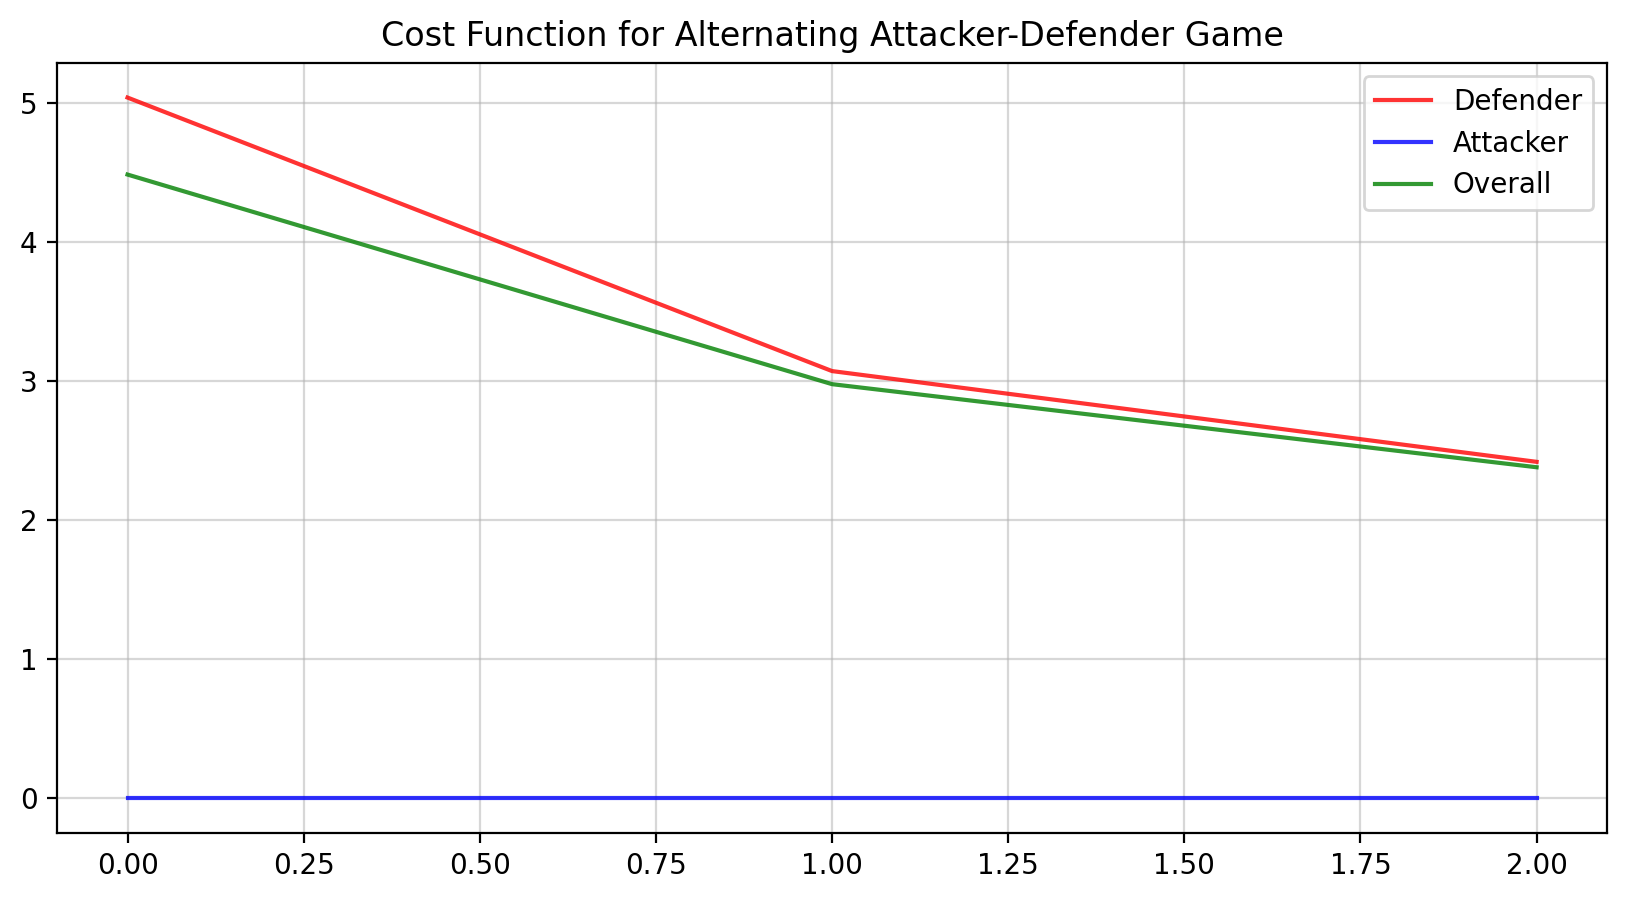

In [ ]:
# Result Evaluatoin
# Cost over Iteration
fig = plt.figure(figsize=(10,5), dpi=200)
iteration = np.linspace(0, max_iters-1, max_iters)
plt.plot(iteration, defender_cost_history, '-r', alpha=0.8, label='Defender')
plt.plot(iteration, attacker_cost_history, '-b', alpha=0.8, label='Attacker')
plt.plot(iteration, payoff_history, '-g', alpha=0.8, label='Overall')
# plt.plot(iteration, gap_history, '-k', alpha=0.8, label='Overall')
plt.grid(alpha=0.5)
plt.legend()
plt.title('Cost Function for Alternating Attacker-Defender Game')
# plt.savefig("image/AD_Game/cost_func_alternating_adgame.png", dpi=300, bbox_inches="tight")

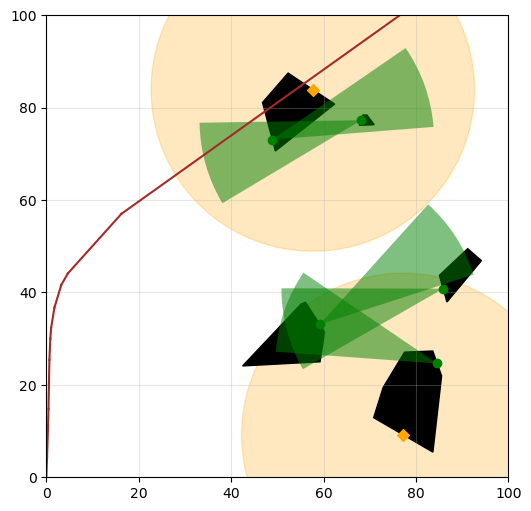

In [ ]:
# Parse Attacker strategy
att_optimal_x = X_star[0,:]
att_optimal_y = X_star[1,:]
att_optimal_t = X_star[2,:]

# Parse Defender strategy
def_optimal_x = S_star[0,:]
def_optimal_y = S_star[1,:]

# Plot Final attacker / defender strategy
# ---- Static map bounds & buildings ----
st = map_in["st"]
size = np.array(st["size"], dtype=float)   # [xmin, xmax, ymin, ymax]
xmin, xmax, ymin, ymax = size

buildings = []
for i in range(st["n"]):
    poly = np.array(st[str(i)], dtype=float)
    buildings.append(poly)

# ---- Cameras & spec ----
# Directional sensors
cx = np.array(def_optimal_x[0:num_direc_sensor], dtype=float)
cy = np.array(def_optimal_y[0:num_direc_sensor], dtype=float)
spec = cam_dict['directional']["spec"]
init_angles = np.array(spec["init_angle"], dtype=float)          # radians
bound_arr = np.array(spec["bound"], dtype=float)                 # (n,2) = [+max, -max]
fov_half = float(spec["fov"][0])                                 # radians
fov_range = float(spec["fov"][1])                                # map units
panspeeds = np.array(spec["panspeed"], dtype=float)              # rad/time

t = 0
# Compute facing angles at time t with bounce pan
facings = np.array([
    _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
    for i in range(len(cx))
], dtype=float)

# Compute facing angles at time t with bounce pan
facings = np.array([
    _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
    for i in range(len(cx))
], dtype=float)

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# Buildings: black
for poly in buildings:
    ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

# Sensors: green circles
ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="Directional sensors")
if cam_dict['n_omni'] != 0:
    # Omnidirectional sensors
    ox = np.array(def_optimal_x[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
    oy = np.array(def_optimal_y[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
    spec_omni = cam_dict['omnidirectional']["spec"]
    fov_half_omni = float(spec["fov"][0])                                 # radians
    fov_range_omni = float(spec["fov"][1])                                # map units
    ax.scatter(ox, oy, s=36, c='orange', marker='D', zorder=3, label='Omnidirectional sensors')
    
    # Omnidirectional sensor
    for i in range(len(ox)):
        omni_circle = plt.Circle((ox[i], oy[i]), fov_range_omni, color='orange', alpha=0.25, clip_on=True, zorder=0)
        ax.add_patch(omni_circle)

sensor_alpha = 0.5
# FOV wedges: green with alpha
for i in range(len(cx)):
    theta_deg = math.degrees(facings[i])
    wedge = Wedge(
        center=(cx[i], cy[i]),
        r=fov_range,
        theta1=theta_deg - math.degrees(fov_half),
        theta2=theta_deg + math.degrees(fov_half),
        facecolor="green",
        edgecolor=None,
        alpha=float(sensor_alpha),
        zorder=2
    )
    ax.add_patch(wedge)
    
# If algorithm result was inputted:
path_alpha=0.15

for pi in range(len(att_optimal_x)-1):
    p0x = att_optimal_x[pi]
    p0y = att_optimal_y[pi]
    p1x = att_optimal_x[pi+1]
    p1y = att_optimal_y[pi+1]
    ax.plot([p0x, p1x], [p0y, p1y], '-', color='brown')

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)